# Análise — Remessas no Chão

Este notebook analisa o arquivo **`no-chao-remessas-todas.xlsx`** e responde perguntas operacionais sobre:

- visão geral da operação;
- evolução diária;
- lojas e rotas;
- tamanho e concentração das remessas;
- relação entre peças e volumes;
- picking e embarque;
- qualidade dos dados;
- Pareto;
- aging das remessas;
- priorização das remessas mais críticas.

> **Como usar:** coloque este notebook na mesma pasta do arquivo `no-chao-remessas-todas.xlsx` e execute as células de cima para baixo.

## 1. Bibliotecas e configurações

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

ARQUIVO = Path("./no-chao-remessas-tp-todas.xlsx")

## 2. Carregamento e preparação da base

In [9]:
if not ARQUIVO.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado: {ARQUIVO.resolve()}\n"
        "Coloque 'no-chao-remessas-todas.xlsx' na mesma pasta do notebook."
    )

df = pd.read_excel(ARQUIVO)
df.columns = df.columns.astype(str).str.strip()

print("Colunas encontradas:", df.columns.tolist())
display(df.head())

Colunas encontradas: ['Remessa', 'Loja', 'Rota', 'ID Embarque', 'ID Picking', 'Data', 'Peças', 'Volumes']


,Remessa,Loja,Rota,ID Embarque,ID Picking,Data,Peças,Volumes
0,504226417,28.00,TP PF 89,244.00,NaN,22/09/2026,825,27
1,504227653,68.00,TP PF 86,249.00,661.00,23/09/2026,2414,83
2,504227820,28.00,TP PF 89,251.00,NaN,23/09/2026,136,8
3,504227820,42.00,TP PF 89,251.00,NaN,23/09/2026,575,16
4,504227820,448.00,TP PF 84A,251.00,NaN,23/09/2026,159,6


In [10]:
# Padronização dos principais campos
colunas_esperadas = [
    "Remessa", "Loja", "Rota", "ID Embarque",
    "ID Picking", "Data", "Peças", "Volumes"
]

faltantes = [c for c in colunas_esperadas if c not in df.columns]
if faltantes:
    print("ATENÇÃO - colunas esperadas não encontradas:", faltantes)

if "Data" in df.columns:
    df["Data"] = pd.to_datetime(df["Data"], errors="coerce", dayfirst=True)

for c in ["Peças", "Volumes"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

for c in ["Remessa", "Loja", "ID Embarque", "ID Picking"]:
    if c in df.columns:
        df[c] = df[c].replace(r"^\s*$", np.nan, regex=True)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Remessa      250 non-null    str           
 1   Loja         249 non-null    float64       
 2   Rota         249 non-null    str           
 3   ID Embarque  249 non-null    float64       
 4   ID Picking   26 non-null     float64       
 5   Data         249 non-null    datetime64[us]
 6   Peças        250 non-null    int64         
 7   Volumes      250 non-null    int64         
dtypes: datetime64[us](1), float64(3), int64(2), str(2)
memory usage: 15.8 KB


## 3. Visão geral

**Perguntas:**
- Quantas remessas existem?
- Quantas peças e volumes estão no chão?
- Quantas lojas e rotas diferentes aparecem?
- Qual a média de peças e volumes por remessa?

In [11]:
resumo = pd.Series({
    "Linhas": len(df),
    "Remessas únicas": df["Remessa"].nunique() if "Remessa" in df else np.nan,
    "Lojas": df["Loja"].nunique() if "Loja" in df else np.nan,
    "Rotas": df["Rota"].nunique() if "Rota" in df else np.nan,
    "Total de peças": df["Peças"].sum() if "Peças" in df else np.nan,
    "Total de volumes": df["Volumes"].sum() if "Volumes" in df else np.nan,
    "Média peças/remessa": df["Peças"].mean() if "Peças" in df else np.nan,
    "Mediana peças/remessa": df["Peças"].median() if "Peças" in df else np.nan,
    "Média volumes/remessa": df["Volumes"].mean() if "Volumes" in df else np.nan,
})
display(resumo.to_frame("Valor"))

,Valor
Linhas,250.00
Remessas únicas,39.00
Lojas,55.00
Rotas,10.00
Total de peças,"294,440.00"
Total de volumes,"8,602.00"
Média peças/remessa,"1,177.76"
Mediana peças/remessa,328.00
Média volumes/remessa,34.41


## 4. Evolução por dia

**Perguntas:**
- Qual dia teve mais remessas?
- Qual dia teve mais peças?
- Qual dia teve mais volumes?
- Existem picos ou quedas fora do padrão?

In [16]:
diario = (
    df.groupby("Data", dropna=False)
      .agg(
          Remessas=("Remessa", "nunique"),
          Peças=("Peças", "sum"),
          Volumes=("Volumes", "sum")
      )
      .reset_index()
      .sort_values("Data")
)

display(diario)

if not diario.empty:
    for metrica in ["Remessas", "Peças", "Volumes"]:
        linha = diario.loc[diario[metrica].idxmax()]
        print(f"Maior {metrica.lower()}: {linha[metrica]:,.0f} em {linha['Data']:%d/%m/%Y}")

,Data,Remessas,Peças,Volumes
0,2026-09-22,2,919,28
1,2026-09-23,4,4254,135
2,2026-09-24,8,23471,588
3,2026-09-25,4,7697,240
4,2026-09-26,4,25716,739
5,2026-09-28,12,54531,1541
6,2026-09-29,4,30632,1030
7,NaT,1,147220,4301


Maior remessas: 12 em 28/09/2026


ValueError: NaTType does not support strftime

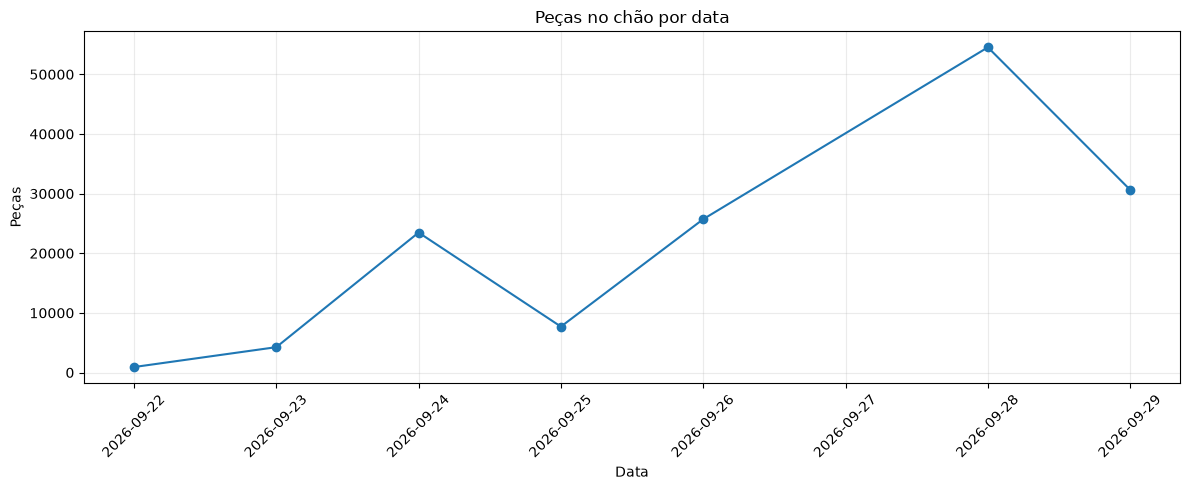

In [17]:
# Gráfico: peças por dia
plot = diario.dropna(subset=["Data"])
if not plot.empty:
    plt.figure(figsize=(12, 5))
    plt.plot(plot["Data"], plot["Peças"], marker="o")
    plt.title("Peças no chão por data")
    plt.xlabel("Data")
    plt.ylabel("Peças")
    plt.xticks(rotation=45)
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

## 5. Análise por loja

**Perguntas:**
- Quais lojas concentram mais peças?
- Quais possuem mais remessas?
- Qual o volume médio por remessa?
- Quais lojas concentram a maior parte da operação?

In [18]:
por_loja = (
    df.groupby("Loja", dropna=False)
      .agg(
          Remessas=("Remessa", "nunique"),
          Peças=("Peças", "sum"),
          Volumes=("Volumes", "sum")
      )
)

por_loja["Peças por remessa"] = por_loja["Peças"] / por_loja["Remessas"]
por_loja["Volumes por remessa"] = por_loja["Volumes"] / por_loja["Remessas"]
por_loja["% das peças"] = por_loja["Peças"] / por_loja["Peças"].sum() * 100

por_loja = por_loja.sort_values("Peças", ascending=False)
display(por_loja.head(20))

,Remessas,Peças,Volumes,Peças por remessa,Volumes por remessa,% das peças
Loja,,,,,,
NaN,1,147220,4301,"147,220.00","4,301.00",50.00
68.00,8,12041,358,"1,505.12",44.75,4.09
360.00,9,11837,313,"1,315.22",34.78,4.02
119.00,6,8993,254,"1,498.83",42.33,3.05
77.00,6,8849,247,"1,474.83",41.17,3.01
42.00,9,8175,221,908.33,24.56,2.78
427.00,7,7232,202,"1,033.14",28.86,2.46
200.00,7,6532,184,933.14,26.29,2.22
73.00,4,6218,167,"1,554.50",41.75,2.11


TypeError: 'value' must be an instance of str or bytes, not a float

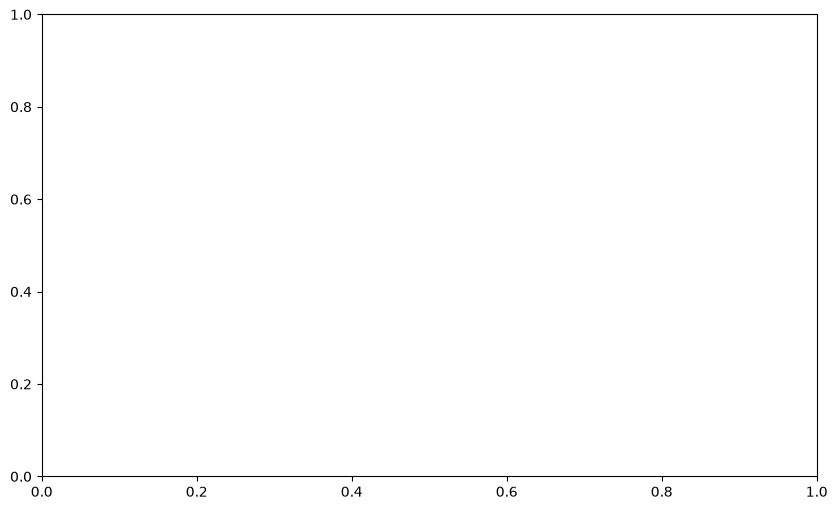

In [19]:
top = por_loja.head(10).sort_values("Peças")
plt.figure(figsize=(10, 6))
plt.barh(top.index.astype(str), top["Peças"])
plt.title("Top 10 lojas por quantidade de peças")
plt.xlabel("Peças")
plt.ylabel("Loja")
plt.tight_layout()
plt.show()

## 6. Análise por rota

**Perguntas:**
- Quais rotas movimentam mais peças e volumes?
- Quantas lojas cada rota atende?
- Qual rota possui mais remessas?

In [20]:
por_rota = (
    df.groupby("Rota", dropna=False)
      .agg(
          Lojas=("Loja", "nunique"),
          Remessas=("Remessa", "nunique"),
          Peças=("Peças", "sum"),
          Volumes=("Volumes", "sum")
      )
      .sort_values("Peças", ascending=False)
)

por_rota["Peças por remessa"] = por_rota["Peças"] / por_rota["Remessas"]
display(por_rota)

,Lojas,Remessas,Peças,Volumes,Peças por remessa
Rota,,,,,
NaN,0,1,147220,4301,"147,220.00"
504-5R,9,15,25013,663,"1,667.53"
TP PF 86,6,15,21770,638,"1,451.33"
504-87,6,11,19098,548,"1,736.18"
TP PF 85,8,16,17628,488,"1,101.75"
TP PF 89,4,18,16962,482,942.33
504-5J,4,10,16528,483,"1,652.80"
TP PF 84A,6,8,9368,323,"1,171.00"
504-88,5,11,8663,278,787.55


In [ ]:
top = por_rota.head(10).sort_values("Peças")
plt.figure(figsize=(10, 6))
plt.barh(top.index.astype(str), top["Peças"])
plt.title("Top 10 rotas por peças")
plt.xlabel("Peças")
plt.ylabel("Rota")
plt.tight_layout()
plt.show()

## 7. Maiores remessas e valores fora do padrão

**Perguntas:**
- Quais são as maiores remessas em peças?
- Quais são as maiores em volumes?
- Existem remessas muito acima da média?

In [21]:
cols = [c for c in ["Remessa", "Loja", "Rota", "Data", "Peças", "Volumes", "ID Picking", "ID Embarque"] if c in df.columns]

print("20 maiores remessas por peças")
display(df.nlargest(20, "Peças")[cols])

print("20 maiores remessas por volumes")
display(df.nlargest(20, "Volumes")[cols])

20 maiores remessas por peças


,Remessa,Loja,Rota,Data,Peças,Volumes,ID Picking,ID Embarque
249,Total (249),NaN,NaN,NaT,147220,4301,NaN,NaN
67,504230858,77.00,504-5J,2026-09-28,3284,82,NaN,266.00
52,504230682,200.00,TP PF 85,2026-09-26,2528,62,NaN,263.00
13,504229204,68.00,TP PF 86,2026-09-24,2514,69,661.00,257.00
15,504229204,398.00,TP PF 85,2026-09-24,2511,54,NaN,257.00
68,504230858,119.00,504-87,2026-09-28,2504,55,NaN,266.00
70,504230858,360.00,504-5R,2026-09-28,2426,53,NaN,266.00
1,504227653,68.00,TP PF 86,2026-09-23,2414,83,661.00,249.00
95,504231208,360.00,504-5R,2026-09-28,2383,63,NaN,266.00
44,504230682,68.00,TP PF 86,2026-09-26,2337,67,NaN,263.00


20 maiores remessas por volumes


,Remessa,Loja,Rota,Data,Peças,Volumes,ID Picking,ID Embarque
249,Total (249),NaN,NaN,NaT,147220,4301,NaN,NaN
1,504227653,68.00,TP PF 86,2026-09-23,2414,83,661.00,249.00
67,504230858,77.00,504-5J,2026-09-28,3284,82,NaN,266.00
13,504229204,68.00,TP PF 86,2026-09-24,2514,69,661.00,257.00
44,504230682,68.00,TP PF 86,2026-09-26,2337,67,NaN,263.00
164,504232776,68.00,TP PF 86,2026-09-29,1931,66,NaN,276.00
117,504232165,119.00,504-87,2026-09-28,2206,64,NaN,269.00
163,504232776,42.00,TP PF 89,2026-09-29,1988,64,NaN,276.00
95,504231208,360.00,504-5R,2026-09-28,2383,63,NaN,266.00
116,504232165,77.00,504-5J,2026-09-28,2248,63,NaN,269.00


In [22]:
# Outliers de peças pelo método IQR
q1 = df["Peças"].quantile(0.25)
q3 = df["Peças"].quantile(0.75)
iqr = q3 - q1
limite = q3 + 1.5 * iqr

outliers_pecas = df[df["Peças"] > limite].sort_values("Peças", ascending=False)

print(f"Q1: {q1:,.0f}")
print(f"Q3: {q3:,.0f}")
print(f"Limite de outlier: {limite:,.0f} peças")
print(f"Remessas acima do limite: {len(outliers_pecas):,}")
display(outliers_pecas[cols].head(30))

Q1: 112
Q3: 850
Limite de outlier: 1,956 peças
Remessas acima do limite: 22


,Remessa,Loja,Rota,Data,Peças,Volumes,ID Picking,ID Embarque
249,Total (249),NaN,NaN,NaT,147220,4301,NaN,NaN
67,504230858,77.00,504-5J,2026-09-28,3284,82,NaN,266.00
52,504230682,200.00,TP PF 85,2026-09-26,2528,62,NaN,263.00
13,504229204,68.00,TP PF 86,2026-09-24,2514,69,661.00,257.00
15,504229204,398.00,TP PF 85,2026-09-24,2511,54,NaN,257.00
68,504230858,119.00,504-87,2026-09-28,2504,55,NaN,266.00
70,504230858,360.00,504-5R,2026-09-28,2426,53,NaN,266.00
1,504227653,68.00,TP PF 86,2026-09-23,2414,83,661.00,249.00
95,504231208,360.00,504-5R,2026-09-28,2383,63,NaN,266.00
44,504230682,68.00,TP PF 86,2026-09-26,2337,67,NaN,263.00


## 8. Relação peças × volumes

**Perguntas:**
- Quantas peças existem, em média, por volume?
- Quais remessas têm muitas peças em poucos volumes?
- Quais têm baixa quantidade de peças por volume?

In [23]:
df["Peças por Volume"] = np.where(
    df["Volumes"] > 0,
    df["Peças"] / df["Volumes"],
    np.nan
)

display(df["Peças por Volume"].describe())

print("Maior relação peças/volume")
display(df.sort_values("Peças por Volume", ascending=False)[cols + ["Peças por Volume"]].head(20))

print("Menor relação peças/volume")
display(
    df[df["Peças por Volume"].notna()]
      .sort_values("Peças por Volume")
      [cols + ["Peças por Volume"]]
      .head(20)
)

count   250.00
mean     37.38
std      15.59
min       5.00
25%      27.93
50%      34.50
75%      43.50
max     108.00
Name: Peças por Volume, dtype: float64

Maior relação peças/volume


,Remessa,Loja,Rota,Data,Peças,Volumes,ID Picking,ID Embarque,Peças por Volume
219,4504232164,"40,057.00",TP PF 86,2026-09-28,108,1,661.00,269.00,108.00
220,4504232164,"40,105.00",504-88,2026-09-28,106,1,NaN,269.00,106.00
188,4504227820,"40,163.00",TP PF 85,2026-09-23,100,1,NaN,251.00,100.00
182,4504226987,"40,119.00",TP PF 89,2026-09-22,94,1,NaN,247.00,94.00
189,4504228484,"40,091.00",504-5R,2026-09-24,352,4,NaN,255.00,88.00
222,4504232164,"40,143.00",TP PF 85,2026-09-28,86,1,NaN,269.00,86.00
187,4504227820,"40,143.00",TP PF 85,2026-09-23,84,1,NaN,251.00,84.00
190,4504228484,"40,111.00",504-5R,2026-09-24,320,4,NaN,255.00,80.00
90,504231205,580.00,TP PF 85,2026-09-28,80,1,NaN,266.00,80.00
184,4504227653,"40,163.00",TP PF 85,2026-09-23,229,3,NaN,249.00,76.33


Menor relação peças/volume


,Remessa,Loja,Rota,Data,Peças,Volumes,ID Picking,ID Embarque,Peças por Volume
32,504229313,600.00,504-88,2026-09-25,5,1,NaN,265.00,5.00
104,504232164,120.00,TP PF 84A,2026-09-28,82,6,NaN,269.00,13.67
56,504230682,600.00,504-88,2026-09-26,253,15,NaN,263.00,16.87
2,504227820,28.00,TP PF 89,2026-09-23,136,8,NaN,251.00,17.00
21,504229313,9.00,TP PF 89,2026-09-25,34,2,NaN,265.00,17.00
186,4504227820,"40,119.00",TP PF 89,2026-09-23,17,1,NaN,251.00,17.00
157,504232705,560.00,504-6,2026-09-29,69,4,NaN,276.00,17.25
100,504232164,42.00,TP PF 89,2026-09-28,106,6,NaN,269.00,17.67
60,504230683,360.00,504-5R,2026-09-26,270,15,NaN,263.00,18.00
185,4504227820,"40,057.00",TP PF 86,2026-09-23,55,3,661.00,251.00,18.33


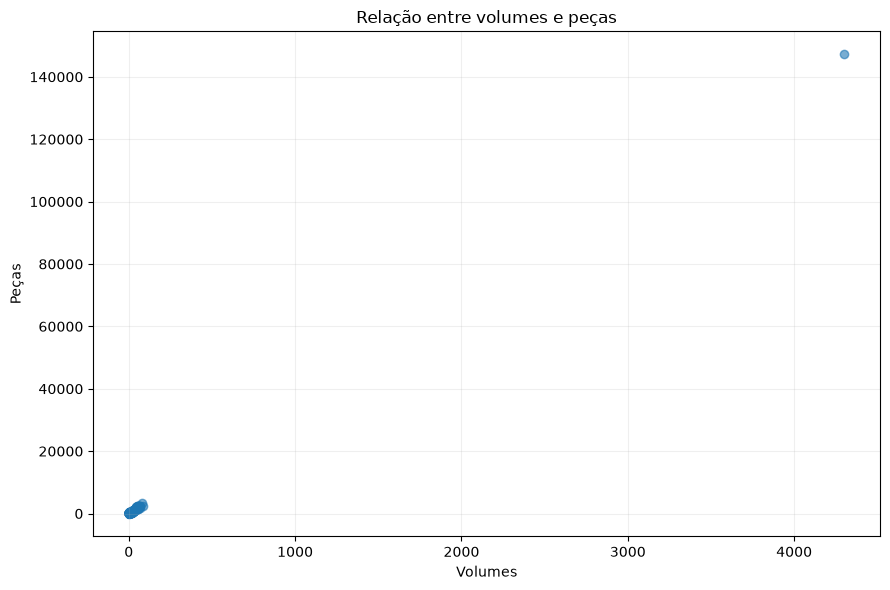

Correlação peças × volumes: 0.9998563219745403


In [24]:
plt.figure(figsize=(9, 6))
plt.scatter(df["Volumes"], df["Peças"], alpha=0.6)
plt.title("Relação entre volumes e peças")
plt.xlabel("Volumes")
plt.ylabel("Peças")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("Correlação peças × volumes:", df[["Peças", "Volumes"]].corr().iloc[0, 1])

## 9. Situação do Picking

**Perguntas:**
- Quantas remessas estão sem ID Picking?
- Qual percentual da base está sem Picking?
- O problema se concentra em alguma loja, rota ou data?

In [25]:
sem_picking = df["ID Picking"].isna()
qtd_sem = sem_picking.sum()
pct_sem = sem_picking.mean() * 100

print(f"Remessas/linhas sem Picking: {qtd_sem:,}")
print(f"Percentual sem Picking: {pct_sem:.2f}%")
print(f"Peças sem Picking: {df.loc[sem_picking, 'Peças'].sum():,.0f}")
print(f"Volumes sem Picking: {df.loc[sem_picking, 'Volumes'].sum():,.0f}")

Remessas/linhas sem Picking: 224
Percentual sem Picking: 89.60%
Peças sem Picking: 278,013
Volumes sem Picking: 8,123


In [26]:
picking_loja = (
    df.assign(Sem_Picking=sem_picking)
      .groupby("Loja")
      .agg(
          Remessas=("Remessa", "nunique"),
          Sem_Picking=("Sem_Picking", "sum"),
          Peças=("Peças", "sum")
      )
)
picking_loja["% sem Picking"] = picking_loja["Sem_Picking"] / picking_loja["Remessas"] * 100
display(picking_loja.sort_values("Sem_Picking", ascending=False).head(20))

,Remessas,Sem_Picking,Peças,% sem Picking
Loja,,,,
42.00,9,9,8175,100.00
360.00,9,9,11837,100.00
28.00,8,8,4140,100.00
"40,119.00",8,8,1727,100.00
200.00,7,7,6532,100.00
427.00,7,7,7232,100.00
"40,163.00",7,7,938,100.00
195.00,6,6,4778,100.00
173.00,6,6,3450,100.00


In [27]:
picking_rota = (
    df.assign(Sem_Picking=sem_picking)
      .groupby("Rota")
      .agg(
          Remessas=("Remessa", "nunique"),
          Sem_Picking=("Sem_Picking", "sum"),
          Peças=("Peças", "sum")
      )
)
picking_rota["% sem Picking"] = picking_rota["Sem_Picking"] / picking_rota["Remessas"] * 100
display(picking_rota.sort_values("Sem_Picking", ascending=False).head(20))

,Remessas,Sem_Picking,Peças,% sem Picking
Rota,,,,
TP PF 85,16,38,17628,237.50
504-5R,15,32,25013,213.33
TP PF 89,18,31,16962,172.22
504-87,11,28,19098,254.55
504-88,11,25,8663,227.27
504-5J,10,22,16528,220.00
TP PF 84A,8,21,9368,262.50
504-6,4,18,8576,450.00
TP PF 86,15,6,21770,40.00


## 10. Situação dos embarques

**Perguntas:**
- Existem remessas sem ID Embarque?
- Um mesmo embarque contém várias remessas?
- Quantas peças e volumes existem por embarque?

In [28]:
sem_embarque = df["ID Embarque"].isna()

print(f"Registros sem ID Embarque: {sem_embarque.sum():,}")
print(f"Percentual sem ID Embarque: {sem_embarque.mean()*100:.2f}%")

embarques = (
    df.dropna(subset=["ID Embarque"])
      .groupby("ID Embarque")
      .agg(
          Remessas=("Remessa", "nunique"),
          Lojas=("Loja", "nunique"),
          Peças=("Peças", "sum"),
          Volumes=("Volumes", "sum")
      )
      .sort_values("Peças", ascending=False)
)

display(embarques.head(30))

Registros sem ID Embarque: 1
Percentual sem ID Embarque: 0.40%


,Remessas,Lojas,Peças,Volumes
ID Embarque,,,,
276.00,4,54,30632,1030
266.00,6,36,29028,772
263.00,4,32,25716,739
257.00,3,14,17272,451
269.00,4,43,16544,525
270.00,2,17,8959,244
265.00,4,20,7697,240
259.00,2,4,4655,114
249.00,2,3,2913,91


## 11. Qualidade dos dados

**Perguntas:**
- Existem remessas duplicadas?
- IDs de Picking repetidos?
- Existem campos faltantes?
- Existem peças ou volumes zerados/negativos?

In [29]:
qualidade = pd.DataFrame({
    "Indicador": [
        "Linhas duplicadas",
        "Remessas duplicadas",
        "ID Picking duplicado (não vazio)",
        "Datas inválidas/vazias",
        "Peças vazias",
        "Volumes vazios",
        "Peças <= 0",
        "Volumes <= 0"
    ],
    "Quantidade": [
        df.duplicated().sum(),
        df["Remessa"].duplicated(keep=False).sum(),
        df.loc[df["ID Picking"].notna(), "ID Picking"].duplicated(keep=False).sum(),
        df["Data"].isna().sum(),
        df["Peças"].isna().sum(),
        df["Volumes"].isna().sum(),
        (df["Peças"] <= 0).sum(),
        (df["Volumes"] <= 0).sum()
    ]
})

display(qualidade)

,Indicador,Quantidade
0,Linhas duplicadas,0
1,Remessas duplicadas,242
2,ID Picking duplicado (não vazio),26
3,Datas inválidas/vazias,1
4,Peças vazias,0
5,Volumes vazios,0
6,Peças <= 0,0
7,Volumes <= 0,0


In [30]:
print("Campos vazios por coluna")
display(
    pd.DataFrame({
        "Vazios": df.isna().sum(),
        "% vazio": df.isna().mean() * 100
    }).sort_values("% vazio", ascending=False)
)

Campos vazios por coluna


,Vazios,% vazio
ID Picking,224,89.60
Data,1,0.40
Loja,1,0.40
Rota,1,0.40
ID Embarque,1,0.40
Remessa,0,0.00
Peças,0,0.00
Volumes,0,0.00
Peças por Volume,0,0.00


## 12. Pareto — concentração da operação

**Perguntas:**
- Quais lojas representam a maior parte das peças?
- Quantas lojas são necessárias para atingir aproximadamente 80% das peças?
- Qual percentual das peças está nas 5 maiores rotas?

In [31]:
pareto_lojas = por_loja.copy().sort_values("Peças", ascending=False)
pareto_lojas["%"] = pareto_lojas["Peças"] / pareto_lojas["Peças"].sum() * 100
pareto_lojas["% acumulado"] = pareto_lojas["%"].cumsum()

qtd_80 = (pareto_lojas["% acumulado"] < 80).sum() + 1

print(f"Lojas necessárias para atingir aproximadamente 80% das peças: {qtd_80}")
display(pareto_lojas.head(20))

top5_rotas_pct = por_rota.head(5)["Peças"].sum() / por_rota["Peças"].sum() * 100
print(f"Participação das 5 maiores rotas: {top5_rotas_pct:.2f}% das peças")

Lojas necessárias para atingir aproximadamente 80% das peças: 13


,Remessas,Peças,Volumes,Peças por remessa,Volumes por remessa,% das peças,%,% acumulado
Loja,,,,,,,,
NaN,1,147220,4301,"147,220.00","4,301.00",50.00,50.00,50.00
68.00,8,12041,358,"1,505.12",44.75,4.09,4.09,54.09
360.00,9,11837,313,"1,315.22",34.78,4.02,4.02,58.11
119.00,6,8993,254,"1,498.83",42.33,3.05,3.05,61.16
77.00,6,8849,247,"1,474.83",41.17,3.01,3.01,64.17
42.00,9,8175,221,908.33,24.56,2.78,2.78,66.95
427.00,7,7232,202,"1,033.14",28.86,2.46,2.46,69.40
200.00,7,6532,184,933.14,26.29,2.22,2.22,71.62
73.00,4,6218,167,"1,554.50",41.75,2.11,2.11,73.73


Participação das 5 maiores rotas: 78.36% das peças


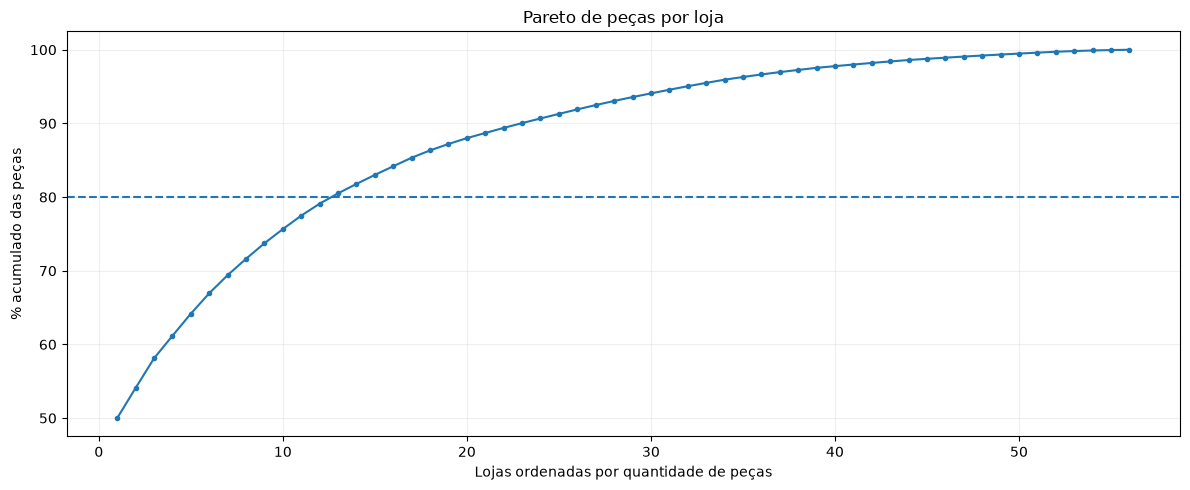

In [32]:
plt.figure(figsize=(12, 5))
x = np.arange(1, len(pareto_lojas) + 1)
plt.plot(x, pareto_lojas["% acumulado"].values, marker="o", markersize=3)
plt.axhline(80, linestyle="--")
plt.title("Pareto de peças por loja")
plt.xlabel("Lojas ordenadas por quantidade de peças")
plt.ylabel("% acumulado das peças")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 13. Aging das remessas

O aging mede há quantos dias a remessa está no chão.

Por padrão, o notebook usa **a maior data da própria base como data de referência**, evitando distorções caso o arquivo seja analisado posteriormente.

**Perguntas:**
- Quantas remessas estão há 0–1, 2–3, 4–5 e 6+ dias?
- Quantas peças e volumes existem em cada faixa?
- Quais são as remessas mais antigas?

In [33]:
DATA_REFERENCIA = df["Data"].max()

df["Aging dias"] = (DATA_REFERENCIA - df["Data"]).dt.days

df["Faixa Aging"] = pd.cut(
    df["Aging dias"],
    bins=[-1, 1, 3, 5, np.inf],
    labels=["0–1 dia", "2–3 dias", "4–5 dias", "6+ dias"]
)

aging = (
    df.groupby("Faixa Aging", observed=False)
      .agg(
          Remessas=("Remessa", "nunique"),
          Peças=("Peças", "sum"),
          Volumes=("Volumes", "sum")
      )
)

print("Data de referência:", DATA_REFERENCIA.strftime("%d/%m/%Y"))
display(aging)

Data de referência: 29/09/2026


,Remessas,Peças,Volumes
Faixa Aging,,,
0–1 dia,16,85163,2571
2–3 dias,4,25716,739
4–5 dias,12,31168,828
6+ dias,6,5173,163


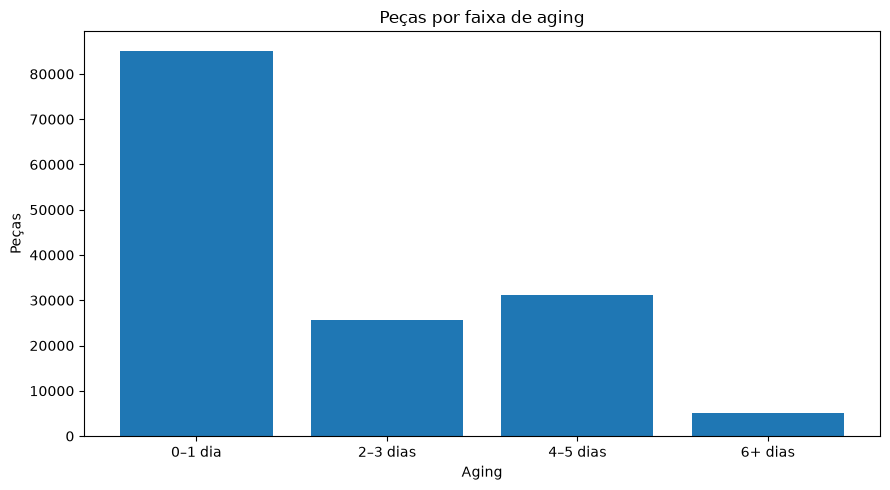

Remessas mais antigas


,Remessa,Loja,Rota,Data,Peças,Volumes,ID Picking,ID Embarque,Aging dias,Faixa Aging
0,504226417,28.00,TP PF 89,2026-09-22,825,27,NaN,244.00,7.00,6+ dias
182,4504226987,"40,119.00",TP PF 89,2026-09-22,94,1,NaN,247.00,7.00,6+ dias
1,504227653,68.00,TP PF 86,2026-09-23,2414,83,661.00,249.00,6.00,6+ dias
3,504227820,42.00,TP PF 89,2026-09-23,575,16,NaN,251.00,6.00,6+ dias
183,4504227653,"40,119.00",TP PF 89,2026-09-23,270,5,NaN,249.00,6.00,6+ dias
184,4504227653,"40,163.00",TP PF 85,2026-09-23,229,3,NaN,249.00,6.00,6+ dias
5,504227820,533.00,TP PF 84A,2026-09-23,215,8,NaN,251.00,6.00,6+ dias
4,504227820,448.00,TP PF 84A,2026-09-23,159,6,NaN,251.00,6.00,6+ dias
2,504227820,28.00,TP PF 89,2026-09-23,136,8,NaN,251.00,6.00,6+ dias
188,4504227820,"40,163.00",TP PF 85,2026-09-23,100,1,NaN,251.00,6.00,6+ dias


In [34]:
plt.figure(figsize=(9, 5))
plt.bar(aging.index.astype(str), aging["Peças"])
plt.title("Peças por faixa de aging")
plt.xlabel("Aging")
plt.ylabel("Peças")
plt.tight_layout()
plt.show()

print("Remessas mais antigas")
display(
    df.sort_values(["Aging dias", "Peças"], ascending=[False, False])
      [cols + ["Aging dias", "Faixa Aging"]]
      .head(30)
)

## 14. Índice de criticidade

Para apoiar a priorização operacional, criamos um indicador exploratório combinando:

- **aging** da remessa;
- **quantidade de peças**;
- **quantidade de volumes**;
- **ausência de ID Picking**.

O índice é uma ferramenta de triagem, não uma regra operacional definitiva. Os pesos podem ser ajustados conforme a realidade da operação.

In [35]:
def normalizar(s):
    s = s.fillna(0)
    minimo, maximo = s.min(), s.max()
    if maximo == minimo:
        return pd.Series(0, index=s.index, dtype=float)
    return (s - minimo) / (maximo - minimo)

df["Crit_Aging"] = normalizar(df["Aging dias"].clip(lower=0))
df["Crit_Peças"] = normalizar(df["Peças"])
df["Crit_Volumes"] = normalizar(df["Volumes"])
df["Crit_Sem_Picking"] = df["ID Picking"].isna().astype(int)

# Pesos ajustáveis
PESO_AGING = 0.40
PESO_PECAS = 0.30
PESO_VOLUMES = 0.15
PESO_SEM_PICKING = 0.15

df["Criticidade"] = 100 * (
    PESO_AGING * df["Crit_Aging"] +
    PESO_PECAS * df["Crit_Peças"] +
    PESO_VOLUMES * df["Crit_Volumes"] +
    PESO_SEM_PICKING * df["Crit_Sem_Picking"]
)

ranking_critico = df.sort_values("Criticidade", ascending=False)

display(
    ranking_critico[
        cols + ["Aging dias", "Peças por Volume", "Criticidade"]
    ].head(30)
)

,Remessa,Loja,Rota,Data,Peças,Volumes,ID Picking,ID Embarque,Aging dias,Peças por Volume,Criticidade
249,Total (249),NaN,NaN,NaT,147220,4301,NaN,NaN,NaN,34.23,60.00
0,504226417,28.00,TP PF 89,2026-09-22,825,27,NaN,244.00,7.00,30.56,55.26
182,4504226987,"40,119.00",TP PF 89,2026-09-22,94,1,NaN,247.00,7.00,94.00,55.02
3,504227820,42.00,TP PF 89,2026-09-23,575,16,NaN,251.00,6.00,35.94,49.45
183,4504227653,"40,119.00",TP PF 89,2026-09-23,270,5,NaN,249.00,6.00,54.00,49.35
5,504227820,533.00,TP PF 84A,2026-09-23,215,8,NaN,251.00,6.00,26.88,49.35
184,4504227653,"40,163.00",TP PF 85,2026-09-23,229,3,NaN,249.00,6.00,76.33,49.34
2,504227820,28.00,TP PF 89,2026-09-23,136,8,NaN,251.00,6.00,17.00,49.34
4,504227820,448.00,TP PF 84A,2026-09-23,159,6,NaN,251.00,6.00,26.50,49.33
188,4504227820,"40,163.00",TP PF 85,2026-09-23,100,1,NaN,251.00,6.00,100.00,49.31


## 15. Resumo executivo automático

Esta célula gera algumas respostas rápidas para apoiar uma reunião operacional.

In [ ]:
total_pecas = df["Peças"].sum()
total_volumes = df["Volumes"].sum()
total_remessas = df["Remessa"].nunique()

loja_top = por_loja.index[0] if len(por_loja) else None
rota_top = por_rota.index[0] if len(por_rota) else None

print("=" * 60)
print("RESUMO EXECUTIVO — REMESSAS NO CHÃO")
print("=" * 60)
print(f"Data de referência: {DATA_REFERENCIA:%d/%m/%Y}")
print(f"Remessas: {total_remessas:,}")
print(f"Peças: {total_pecas:,.0f}")
print(f"Volumes: {total_volumes:,.0f}")
print(f"Lojas: {df['Loja'].nunique():,}")
print(f"Rotas: {df['Rota'].nunique():,}")
print()
print(f"Loja com maior quantidade de peças: {loja_top}")
print(f"Rota com maior quantidade de peças: {rota_top}")
print(f"Registros sem Picking: {sem_picking.sum():,} ({sem_picking.mean()*100:.2f}%)")
print(f"Peças sem Picking: {df.loc[sem_picking, 'Peças'].sum():,.0f}")
print(f"Lojas para atingir ~80% das peças: {qtd_80}")
print(f"Participação das 5 maiores rotas: {top5_rotas_pct:.2f}%")
print()
print("TOP 10 REMESSAS MAIS CRÍTICAS")
display(
    ranking_critico[
        [c for c in ["Remessa","Loja","Rota","Data","Peças","Volumes","ID Picking","Aging dias","Criticidade"] if c in ranking_critico]
    ].head(10)
)

## 16. Exportação dos resultados

Gera um arquivo Excel com as principais tabelas analíticas.

In [ ]:
SAIDA = "analise_no_chao_resultados.xlsx"

with pd.ExcelWriter(SAIDA, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Base Tratada", index=False)
    diario.to_excel(writer, sheet_name="Por Dia", index=False)
    por_loja.reset_index().to_excel(writer, sheet_name="Por Loja", index=False)
    por_rota.reset_index().to_excel(writer, sheet_name="Por Rota", index=False)
    aging.reset_index().to_excel(writer, sheet_name="Aging", index=False)
    ranking_critico.to_excel(writer, sheet_name="Criticidade", index=False)
    qualidade.to_excel(writer, sheet_name="Qualidade", index=False)

print(f"Arquivo gerado: {SAIDA}")

## Próximas perguntas que este notebook permite responder

Depois da primeira execução, vale investigar especialmente:

1. **Onde está concentrado o maior saldo de peças no chão?**
2. **Quais lojas e rotas devem receber atenção operacional?**
3. **Quais remessas combinam alto aging e grande quantidade de peças?**
4. **O saldo sem Picking está concentrado em lojas ou rotas específicas?**
5. **O crescimento do saldo é pontual ou recorrente?**
6. **Quais remessas fogem do padrão de peças por volume?**
7. **Quanto da operação está concentrado nas maiores lojas e rotas?**
8. **Qual seria o impacto de eliminar primeiro as 10, 20 ou 50 remessas mais críticas?**